# Joint training loss comparison: Run A to Run E

This notebook reads the `history.json` files under `outputs/cms_Joint/` and
plots:

1. Run A, B, C, D, E joint training loss on the same axes.
2. The same comparison on an **optimizer-update** axis, which fairly accounts
   for Run E's full-pass epoch definition.
3. Run E's full loss decomposition: total loss, J/psi and Z region losses, and
   every available component loss term.

Losses are taken from `history.json` -> `train.loss`, plus the per-region and
per-component keys stored there.


In [2]:
# --- setup ---------------------------------------------------------------
from pathlib import Path

import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "scaffold").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "scaffold"
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "scaffold" else NOTEBOOK_DIR
FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAMES = [
    ("Run A", "Run_A"),
    ("Run B", "Run_B"),
    ("Run C", "Run_C"),
    ("Run D", "Run_D"),
    ("Run E", "Run_E"),
]

COLORS = {
    "Run A": "#1f77b4",
    "Run B": "#ff7f0e",
    "Run C": "#2ca02c",
    "Run D": "#d62728",
    "Run E": "#9467bd",
}

print("Repo root:", REPO_ROOT.resolve())
print("Run dirs:", [name for _, name in RUN_NAMES])


Repo root: C:\Users\AhrixMarin\Desktop\otus
Run dirs: ['Run_A', 'Run_B', 'Run_C', 'Run_D', 'Run_E']


In [3]:
# --- load histories and helpers ------------------------------------------

def history_path(label, directory):
    return REPO_ROOT / "outputs" / "cms_Joint" / directory / "history.json"

def config_path(label, directory):
    return REPO_ROOT / "outputs" / "cms_Joint" / directory / "config.resolved.json"

def load_history(label, directory):
    path = history_path(label, directory)
    if not path.exists():
        raise FileNotFoundError(f"Missing history file: {path}")
    history = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(history, list) or not history:
        raise ValueError(f"Empty history: {path}")
    return history

def load_steps_per_epoch(label, directory):
    path = config_path(label, directory)
    if path.exists():
        config = json.loads(path.read_text(encoding="utf-8"))
        loaders = config.get("loaders", {})
        if loaders.get("epoch_definition") == "full_pass":
            return None
        return int(loaders.get("steps_per_epoch", 0))
    return None

def extract(history, key):
    epochs = np.asarray([row["global_epoch"] for row in history], dtype=float)
    values = np.asarray([row["train"].get(key, np.nan) for row in history], dtype=float)
    return epochs, values

def cumulative_update_axis(history, steps_per_epoch):
    """Return the total optimizer updates completed at the end of each epoch."""
    total = 0.0
    totals = []
    for row in history:
        recorded = row.get("train", {}).get("optimizer_updates")
        if recorded is not None:
            total += float(recorded)
        elif steps_per_epoch is not None:
            total += float(steps_per_epoch)
        totals.append(total)
    return np.asarray(totals, dtype=float)

def moving_average(values, window=5):
    window = max(1, min(int(window), len(values)))
    if window == 1:
        return values
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(values, kernel, mode="valid")

def safe_log_values(values):
    """Return log-friendly values: zeros/negative become NaN for plotting."""
    values = np.asarray(values, dtype=float)
    return np.where(values > 0.0, values, np.nan)

def stage_guides(ax, history):
    starts = []
    previous = None
    for row in history:
        stage = str(row["stage"])
        if stage != previous:
            starts.append((int(row["global_epoch"]), stage))
            previous = stage
    final_epoch = int(history[-1]["global_epoch"])
    for index, (start, _) in enumerate(starts):
        end = starts[index + 1][0] - 1 if index + 1 < len(starts) else final_epoch
        ax.axvspan(start, end, color="#718096", alpha=0.04 if index % 2 == 0 else 0.09)
        if index:
            ax.axvline(start - 0.5, color="#718096", linewidth=0.7, alpha=0.4)
        ax.text(
            (start + end) / 2,
            0.02,
            f"Stage {index + 1}",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=7,
            color="#4a5568",
        )

HISTORIES = {}
CONFIGS = {}
for label, directory in RUN_NAMES:
    HISTORIES[label] = load_history(label, directory)
    CONFIGS[label] = load_steps_per_epoch(label, directory)
    print(f"{label}: {len(HISTORIES[label])} epochs, "
          f"steps/epoch={CONFIGS[label] if CONFIGS[label] is not None else 'full-pass'}")


Run A: 360 epochs, steps/epoch=3
Run B: 360 epochs, steps/epoch=3
Run C: 432 epochs, steps/epoch=4
Run D: 432 epochs, steps/epoch=4
Run E: 432 epochs, steps/epoch=full-pass


## 1. Run A-E joint training loss, same graph

The x-axis is **global epoch**. Since Run E uses a full-pass epoch with many
more optimizer updates per epoch, a second comparison below uses the optimizer
update count as a fairer progress axis.


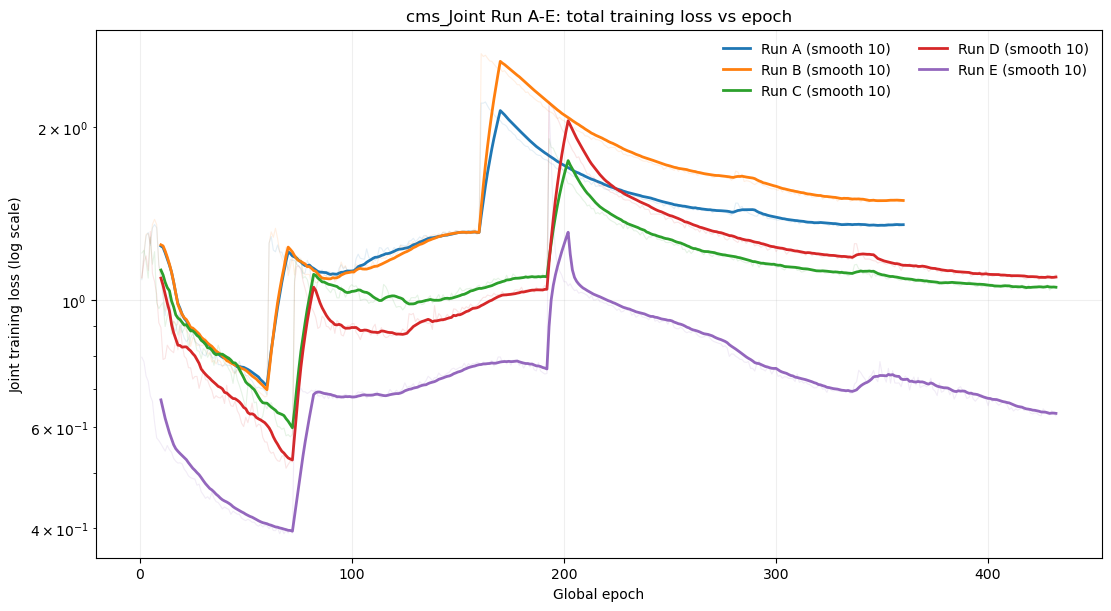

Saved: C:\Users\AhrixMarin\Desktop\otus\scaffold\figures\loss_comparison_A_E_epoch.png


In [4]:
# --- Figure 1: loss vs global epoch -------------------------------------
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

for label, directory in RUN_NAMES:
    history = HISTORIES[label]
    epochs, loss = extract(history, "loss")
    ax.plot(epochs, loss, color=COLORS[label], alpha=0.12, linewidth=0.8)
    ma = moving_average(loss, window=10)
    ax.plot(epochs[len(epochs) - len(ma):], ma, color=COLORS[label],
            linewidth=2.0, label=f"{label} (smooth 10)")

ax.set_yscale("log")
ax.set_xlabel("Global epoch")
ax.set_ylabel("Joint training loss (log scale)")
ax.set_title("cms_Joint Run A-E: total training loss vs epoch")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)

path = FIG_DIR / "loss_comparison_A_E_epoch.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", path.resolve())


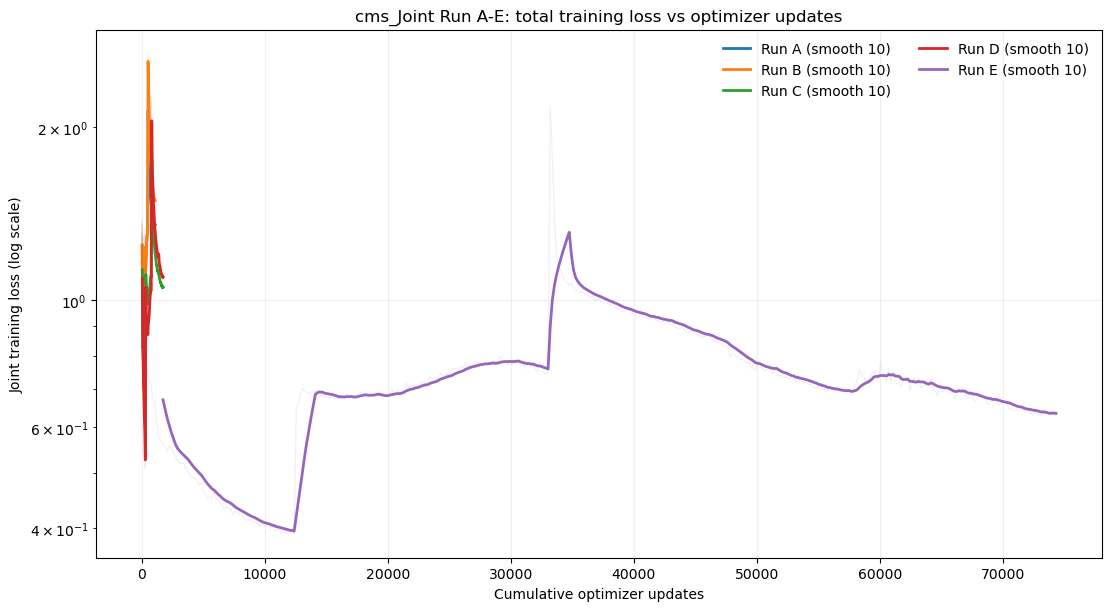

Saved: C:\Users\AhrixMarin\Desktop\otus\scaffold\figures\loss_comparison_A_E_updates.png


In [5]:
# --- Figure 2: loss vs cumulative optimizer updates ----------------------
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

for label, directory in RUN_NAMES:
    history = HISTORIES[label]
    loss_epochs, loss = extract(history, "loss")
    updates = cumulative_update_axis(history, CONFIGS[label])
    ax.plot(updates, loss, color=COLORS[label], alpha=0.12, linewidth=0.8)
    ma = moving_average(loss, window=10)
    ma_updates = updates[len(updates) - len(ma):]
    ax.plot(ma_updates, ma, color=COLORS[label],
            linewidth=2.0, label=f"{label} (smooth 10)")

ax.set_yscale("log")
ax.set_xlabel("Cumulative optimizer updates")
ax.set_ylabel("Joint training loss (log scale)")
ax.set_title("cms_Joint Run A-E: total training loss vs optimizer updates")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)

path = FIG_DIR / "loss_comparison_A_E_updates.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", path.resolve())


## 2. Run E loss decomposition

This plot shows every recorded Run E loss term:

- **Top panel:** total joint loss plus J/psi and Z region totals.
- **Middle panel:** J/psi cycle reconstruction, latent prior, direct
  simulation, and anchor terms.
- **Bottom panel:** the same component losses for Z.

Log scale is used because reconstruction and anchor terms are much smaller
than the distribution-matching terms. The vertical shading shows the four
training stages.


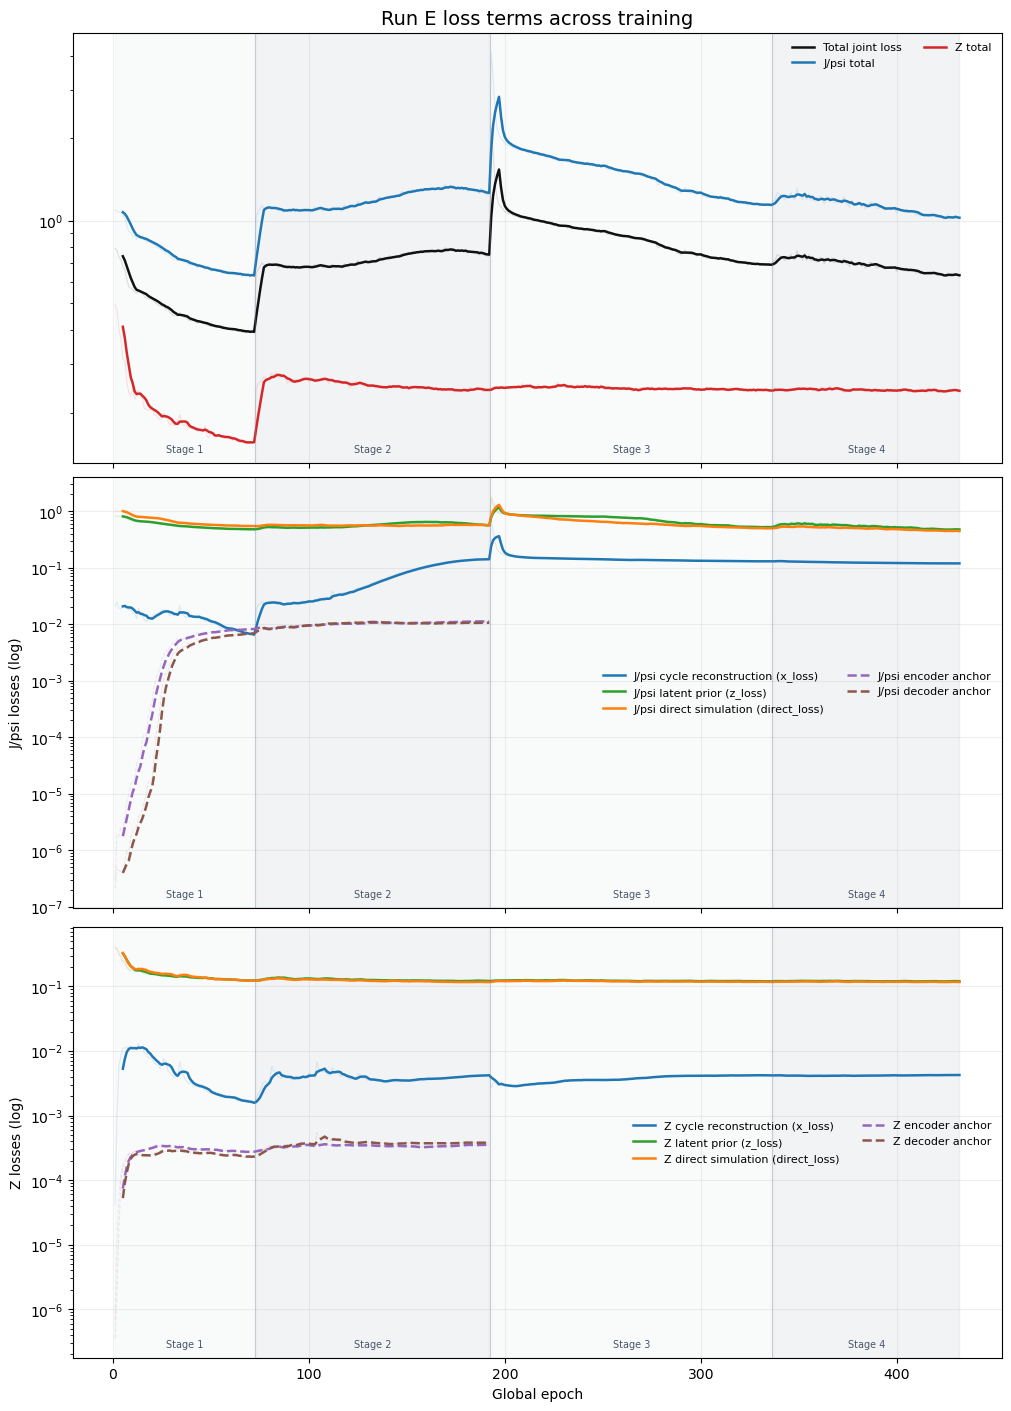

Saved: C:\Users\AhrixMarin\Desktop\otus\scaffold\figures\Run_E_all_loss_terms.png


In [6]:
# --- Figure 3: Run E all loss terms -------------------------------------
RUN_E_LABEL = "Run E"
history = HISTORIES[RUN_E_LABEL]
epochs = np.asarray([row["global_epoch"] for row in history], dtype=float)

def add_series(ax, key, color, style="-", label=None, width=1.8):
    values = np.asarray([row["train"].get(key, np.nan) for row in history], dtype=float)
    finite = np.isfinite(values) & (values > 0.0)
    if not np.any(finite):
        return
    x = epochs[finite]
    y = values[finite]
    ax.plot(x, y, color=color, linestyle=style, alpha=0.12, linewidth=0.8)
    y_ma = moving_average(y, window=5)
    x_ma = x[len(x) - len(y_ma):]
    ax.plot(x_ma, y_ma, color=color, linestyle=style,
            linewidth=width, label=label if label is not None else key)

fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True, constrained_layout=True)

# Top: totals
add_series(axes[0], "loss", "#111111", label="Total joint loss")
add_series(axes[0], "jpsi_loss", "#1f77b4", label="J/psi total")
add_series(axes[0], "z_loss", "#d62728", label="Z total")

# Middle: J/psi components
add_series(axes[1], "jpsi_x_loss", "#1f77b4", label="J/psi cycle reconstruction (x_loss)")
add_series(axes[1], "jpsi_z_loss", "#2ca02c", label="J/psi latent prior (z_loss)")
add_series(axes[1], "jpsi_direct_loss", "#ff7f0e", label="J/psi direct simulation (direct_loss)")
add_series(axes[1], "jpsi_encoder_anchor", "#9467bd", "--", label="J/psi encoder anchor")
add_series(axes[1], "jpsi_decoder_anchor", "#8c564b", "--", label="J/psi decoder anchor")

# Bottom: Z components
add_series(axes[2], "z_x_loss", "#1f77b4", label="Z cycle reconstruction (x_loss)")
add_series(axes[2], "z_z_loss", "#2ca02c", label="Z latent prior (z_loss)")
add_series(axes[2], "z_direct_loss", "#ff7f0e", label="Z direct simulation (direct_loss)")
add_series(axes[2], "z_encoder_anchor", "#9467bd", "--", label="Z encoder anchor")
add_series(axes[2], "z_decoder_anchor", "#8c564b", "--", label="Z decoder anchor")

for ax in axes:
    stage_guides(ax, history)
    ax.set_yscale("log")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8, ncol=2)

axes[0].set_title("Run E loss terms across training", fontsize=14)
axes[1].set_ylabel("J/psi losses (log)")
axes[2].set_ylabel("Z losses (log)")
axes[2].set_xlabel("Global epoch")

path = FIG_DIR / "Run_E_all_loss_terms.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", path.resolve())
